# Study of population & spectrum peaks imabalnce, out of resonance.
## Population study
1. Plot populations of $\ket{+}$ and $\ket{-}$ Vs. $\omega_{THz}$ for different $\Delta_q$
2. Comparision with analytical results
3. Turn it into a map for a bigger set of $Delta_q$

## Spectrum study
1. Plot spectrum ratio for different $\Delta_q$
2. Extract area for left and right peaks
3. Comparision of numerical and analytical results for the area ratio

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

Parameters

In [19]:
kappa_b = 1 #decay en la cav de THz
gamma = 1e-4 * kappa_b # decay en el qubit

chi =  0.1*kappa_b      # acoplo qubit con THz

Omega = 200 * kappa_b  # en uds de kappa_b y 1e6 veces mayor que gamma

Nb = 3         # segunda cavidad

w_THz_list = np.linspace(0, 400, 91)


# eje vertical (detuning del qubit)
Delta_q_list = np.linspace(0, 0.3*Omega, 6)
# eje horizontal (frecuencia espectral)
Delta_a_list = np.linspace(-3*Omega, 3*Omega, 91)

Operators

In [20]:
sx = tensor(sigmax(), qeye(Nb))
sz = tensor(sigmaz(), qeye(Nb))
sm = tensor(sigmam(), qeye(Nb))

b = tensor(qeye(2), destroy(Nb))
b_dag = b.dag()

# Disipadores
D_with = [
    np.sqrt(gamma) * sm,
    np.sqrt(kappa_b) * b
]

num_Pplus_matrix = np.zeros((len(Delta_q_list),len(w_THz_list)))

# 1. Population imbalance graphs

### 1.1:  Numerical calculation

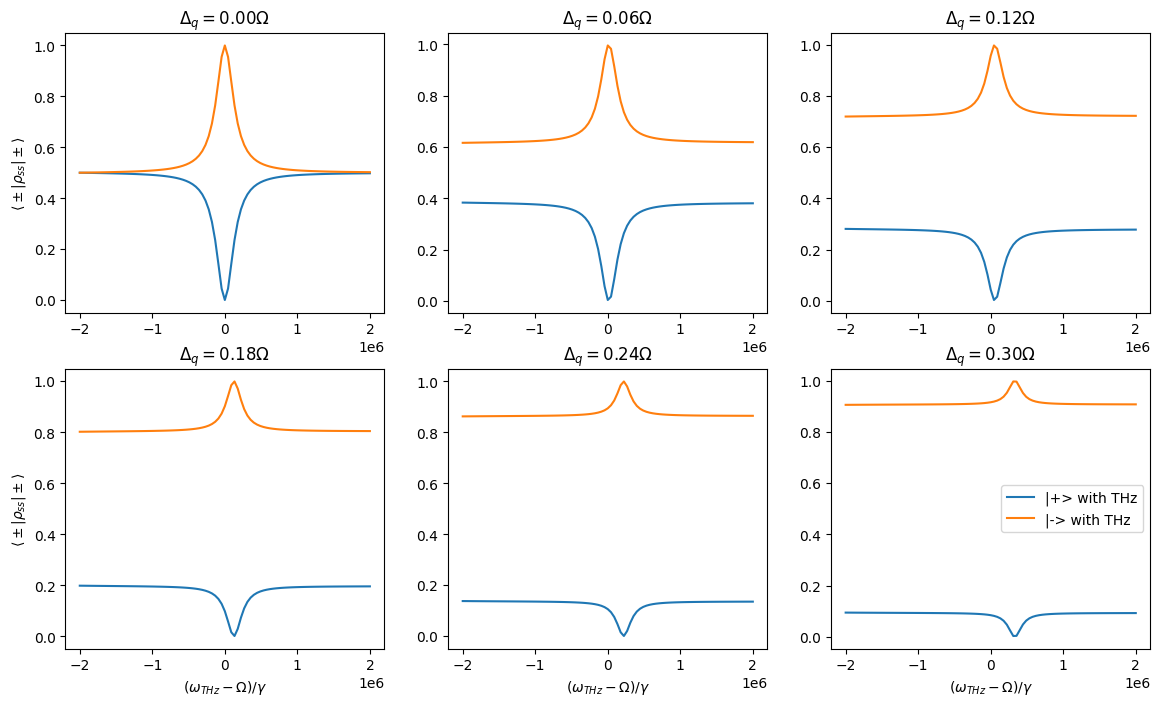

Text(0.5, 0.98, 'Dressed-states population imbalance$')

<Figure size 640x480 with 0 Axes>

In [21]:
figPops, axPops = plt.subplots(2,3, figsize=(14,8))
axPops = axPops.flatten()

nrows, ncols = 2, 3

for idx, Delta_q in enumerate(Delta_q_list):
    # vectors where we store the population @ each w_b
    pops_plus = []
    pops_minus = []
    axP = axPops[idx]
    x_axis = w_THz_list - Omega* np.ones(len(w_THz_list))

    for w_b in w_THz_list:

        H_qubit = (Omega/2)*sigmax() + Delta_q*sigmaz()
        eigvals, eigstates = H_qubit.eigenstates()

        plus_state = eigstates[1]  # mayor energía
        minus_state = eigstates[0] #menor energía

        # extender al espacio total
        plus = tensor(eigstates[1], qeye(Nb))
        P_plus = plus * plus.dag()

        minus = tensor(eigstates[0], qeye(Nb))
        P_minus = minus * minus.dag()

        H = (Omega/2)*sx + Delta_q * sz + w_b * b_dag * b + chi * (sz + 1) * (b + b_dag)

        rho_ss_with = steadystate(H, D_with)
        pop_plus= expect(P_plus, rho_ss_with)
        pop_minus = expect(P_minus, rho_ss_with)

        pops_minus.append(pop_minus)
        pops_plus.append(pop_plus)

    num_Pplus_matrix[idx,:] = pops_plus
    # =========================
    # Gráficas
    # =========================

    axP.plot(x_axis/gamma, pops_plus, label="|+> with THz")
    axP.plot(x_axis/gamma, pops_minus, label="|-> with THz")

    axP.set_title(rf"$\Delta_q = {Delta_q/Omega:.2f}\Omega$")
    #axP.set_title(rf"$\Delta_q = {Delta_q/kappa_b:.2f}\Kappa_b$")
     # ---------------------------
    # 1) ylabel solo primera columna
    # ---------------------------
    if idx % ncols == 0:
        axP.set_ylabel(r"$\langle \pm | \rho_{ss} | \pm \rangle$")
    else:
        axP.set_ylabel("")

    # ---------------------------
    # 2) xlabel solo última fila
    # ---------------------------
    if idx // ncols == nrows - 1:
        axP.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
    else:
        axP.set_xlabel("")

    # ---------------------------
    # 3) leyenda solo último panel
    # ---------------------------
    if idx == len(axPops) - 1:
        axP.legend()

plt.show()
plt.tight_layout()
figPops.suptitle(r"Dressed-states population imbalance$", fontsize=14)


### 1.2: analytical $\langle \xi^\dagger \xi \rangle$ for the different $\Delta_q $.

$$\Omega_R = 2\sqrt{\Delta_q ^2 + \frac{\Omega^2}{4} }$$
$$h = \frac{\Omega_R - 2\Delta_q}{\Omega}\longrightarrow \theta\equiv arctan(h)$$
with $\theta\in[0,\pi/4]$


In [22]:
# Firts of all: define the theta angles for each Delta_q
theta_list = np.zeros(len(Delta_q_list))
for idx, Delta_q in enumerate(Delta_q_list):
    Omega_R = 2*np.sqrt(Delta_q**2+Omega**2/4)
    h = (Omega_R - 2*Delta_q)/Omega
    theta = np.arctan(h)
    theta_list[idx] = theta

print(theta_list)

[0.78539816 0.7256837  0.66762567 0.61262037 0.56163818 0.51518841]


Now, for the analytical expression of $\langle \xi^\dagger \xi \rangle$ we had arrived at:
$$ \langle \xi^\dagger \xi \rangle  = \frac{\gamma\cos^4\theta}{\gamma\cos^4\theta + \gamma\sin^4\theta + \Gamma_P}$$

where $\Gamma_P$ is the Purcell factor, given by: $\Gamma_P = \frac{g^2\gamma}{(\omega_b-\Omega)^2+\gamma^2/4}$, with $g=2\chi\cos\theta\sin\theta$.

### 1.3: Comparision. Numerical Vs Analytical

0.7853981633974483
0.7256837003882791
0.6676256730370167
0.6126203731065923
0.5616381758188633
0.5151884132621563


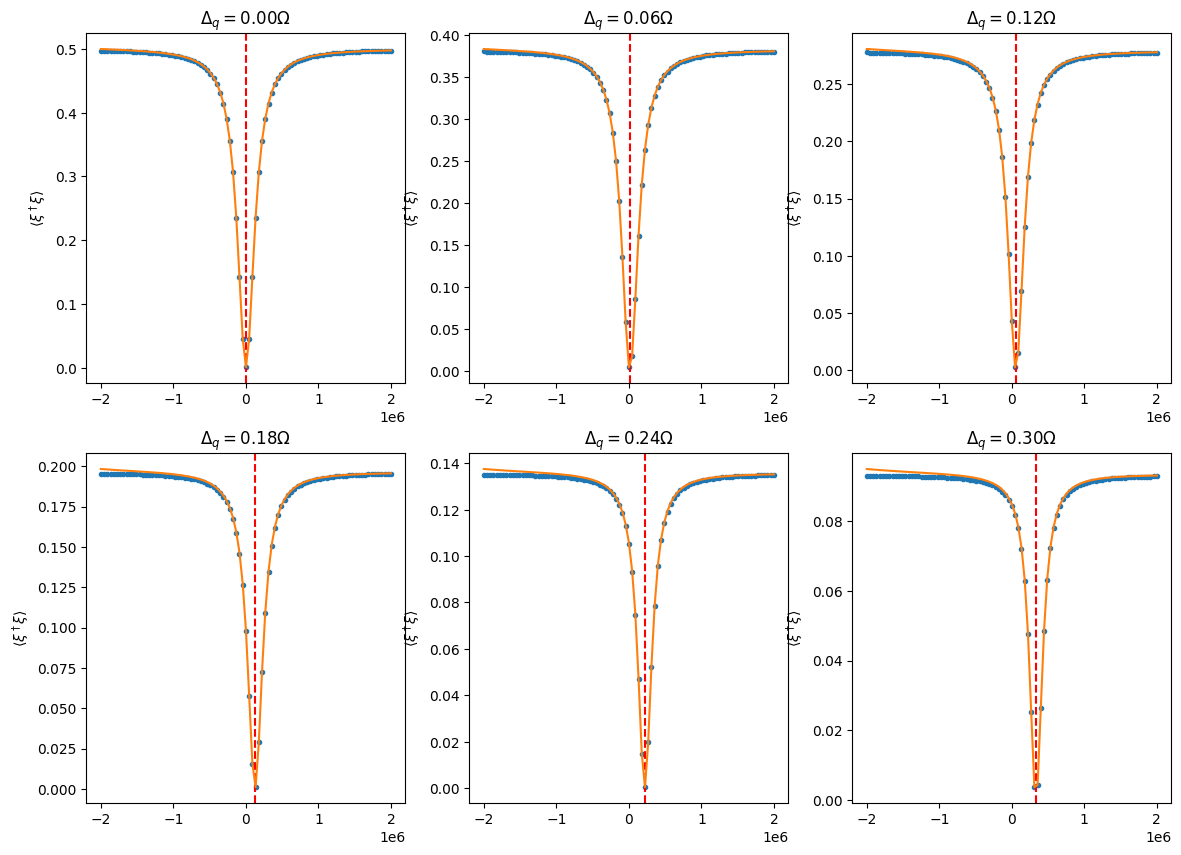

Text(0.5, 0.98, 'Numerical Vs. analytical population imbalance')

<Figure size 640x480 with 0 Axes>

In [24]:
figN, axesN= plt.subplots(2,3, figsize = (14,10))
axesN = axesN.flatten()

for idx, Delta_q in enumerate(Delta_q_list):
    Omega_R = 2*np.sqrt(Delta_q**2+Omega**2/4)
    h = (Omega_R - 2*Delta_q)/Omega
    theta = np.arctan(h)
        
    pops_plus = num_Pplus_matrix[idx,:] # parte calculada numéricamente

    print(theta)
    axN = axesN[idx]

    cos = np.sin(theta)
    sin = np.cos(theta)
    g_eff = 2*chi*sin*cos # acoplo efectivo
    
    pump =  gamma* cos**4
    decay = gamma * sin**4
    P_plus_an = np.zeros(len(w_THz_list))
    
    for idx, w_b in enumerate(w_THz_list):
        Purcell = g_eff**2*kappa_b / ( (w_b-Omega_R)**2 + kappa_b**2/4 ) 
        P_plus_an[idx] = pump/(pump + decay + Purcell)


    axN.plot(x_axis/gamma, P_plus_an,'.', label = 'analytical')
    # Add vertical line at Omega_R
    axN.axvline((Omega_R-Omega)/gamma, color='r', linestyle='--', label=r'$\Omega_R$')
    axN.plot(x_axis/gamma, pops_plus, label = 'numerical')

    axN.set_title(rf"$\Delta_q = {Delta_q/Omega:.2f}\Omega$")

    # ---------------------------
    # 1) ylabel solo primera columna
    # ---------------------------
    if idx % ncols == 0:
        axN.set_ylabel(r"$\langle \xi^\dagger\xi \rangle$")
    else:
        axN.set_ylabel("")

    # ---------------------------
    # 2) xlabel solo última fila
    # ---------------------------
    if idx // ncols == nrows - 1:
        axN.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
    else:
        axN.set_xlabel("")

    # ---------------------------
    # 3) leyenda solo último panel
    # ---------------------------
    if idx == 5:
        axN.legend()

plt.show()
plt.tight_layout()
figN.suptitle(r"Numerical Vs. analytical population imbalance", fontsize=14)

0.7853981633974483
0.7256837003882791
0.6676256730370167
0.6126203731065923
0.5616381758188633
0.5151884132621563


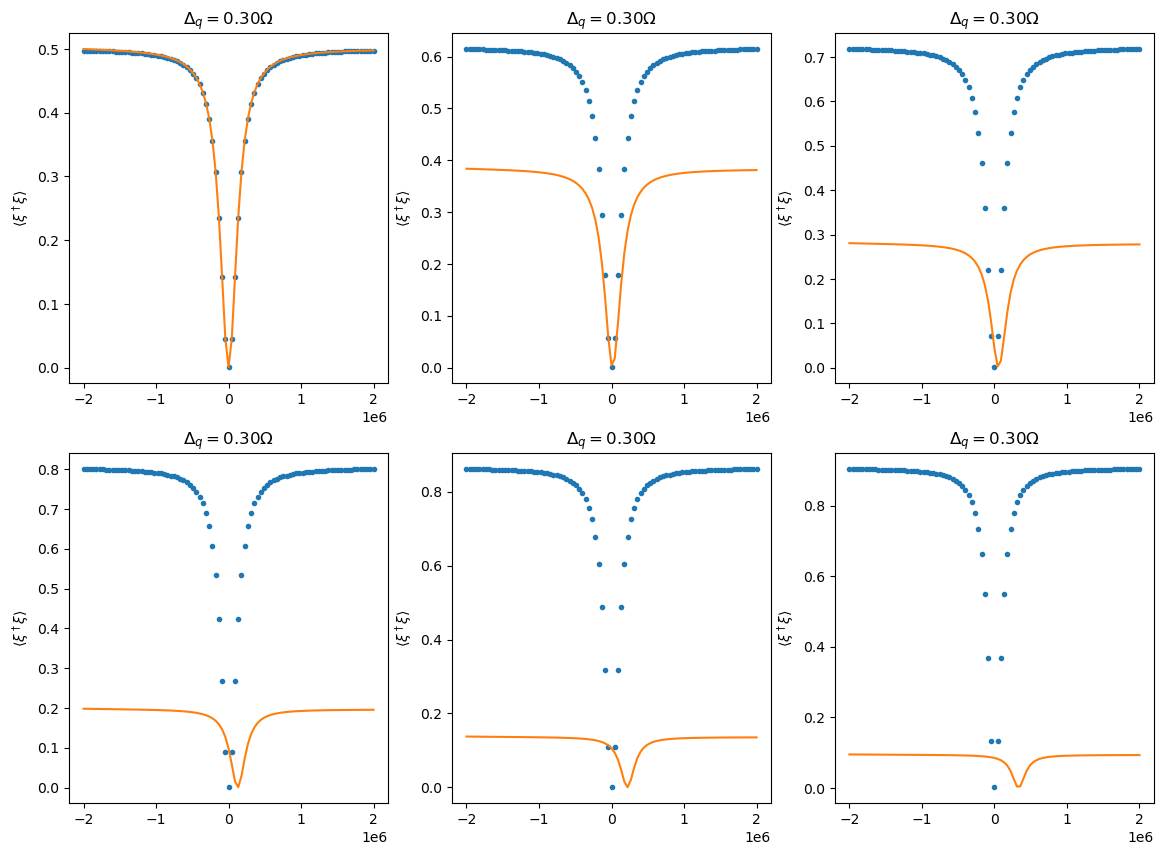

Text(0.5, 0.98, 'Numerical Vs. analytical of population imbalance$')

<Figure size 640x480 with 0 Axes>

In [ ]:
# figN, axesN= plt.subplots(2,3, figsize = (14,10))
# axesN = axesN.flatten()

# for idx, theta in enumerate (theta_list):
    
#     pops_plus = num_Pplus_matrix[idx,:] # parte calculada numéricamente

#     print(theta)
#     axN = axesN[idx]

#     cos = np.cos(theta)
#     sin = np.sin(theta)
#     g_eff = 2*chi*sin*cos # acoplo efectivo
    
#     pump =  gamma* cos**4
#     decay = gamma * sin**4
#     P_plus_an = np.zeros(len(w_THz_list))
    
#     for idx, w_b in enumerate(w_THz_list):
#         Purcell = g_eff**2*kappa_b / ( (w_b-Omega)**2 + kappa_b**2/4 ) # ERROR: Debería ser la Rabi frequency, no Omega. 
#         P_plus_an[idx] = pump/(pump + decay + Purcell)

#     axN.plot(x_axis/gamma, P_plus_an,'.', label = 'analytical')
#     axN.plot(x_axis/gamma, pops_plus, label = 'numerical')

#     axN.set_title(rf"$\Delta_q = {Delta_q/Omega:.2f}\Omega$")

#     # ---------------------------
#     # 1) ylabel solo primera columna
#     # ---------------------------
#     if idx % ncols == 0:
#         axN.set_ylabel(r"$\langle \xi^\dagger\xi \rangle$")
#     else:
#         axN.set_ylabel("")

#     # ---------------------------
#     # 2) xlabel solo última fila
#     # ---------------------------
#     if idx // ncols == nrows - 1:
#         axN.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
#     else:
#         axN.set_xlabel("")

#     # ---------------------------
#     # 3) leyenda solo último panel
#     # ---------------------------
#     if idx == 5:
#         axN.legend()

# plt.show()
# plt.tight_layout()
# figN.suptitle(r"Numerical Vs. analytical population imbalance", fontsize=14)

# 2. Spectra
- First of all: draw the spectra at different $\Delta_q$ to identify where we perform the lorentzian fit of each peak. 
Map of S(Delta_a, w_b) for each Delta_q
- Perform the fit
- numerical vs analytical calculation

Now we have to expand the Hilbert space, to include the sensor

In [56]:
kappa_a = 1
g = 0.001       # acoplo qubit con el sensor
Na = 2        # truncación de la primera cavidad 

# Operadores en el espacio producto tensorial
sx = tensor( sigmax(), qeye(Na), qeye(Nb))
sp = tensor( sigmap(), qeye(Na), qeye(Nb))
sm = tensor( sigmam(), qeye(Na), qeye(Nb))
sz = tensor( sigmaz(), qeye(Na), qeye(Nb))

a = tensor( qeye(2), destroy(Na) , qeye(Nb))
a_plus = a.dag()

b = tensor( qeye(2), qeye(Na), destroy(Nb))
b_plus = b.dag()

# Disipadores
Dissipators = []

Dissipators.append(np.sqrt(gamma) * sm)
Dissipators.append(np.sqrt(kappa_a) * a)
Dissipators.append(np.sqrt(kappa_b) * b)

Omega_R = 2*np.sqrt(Delta_q**2+(Omega/2)**2)

### 2.1 Complete spectrum figures at different $\Delta_q$

In [57]:
# Diccionario para guardar todos los mapas por valor de Delta_q
all_S_maps = {}

# Doble bucle
for idx, w_b in enumerate(w_THz_list):

    S_map = np.zeros((len(w_THz_list), len(Delta_a_list)))

    for i, w_b in enumerate(w_THz_list):
        
        for j, Delta_a in enumerate(Delta_a_list):
            
        # Hamiltoniano
            H = (Omega/2) * sx \
            + Delta_a * a_plus * a + Delta_q * sz \
            + w_b * b_plus * b \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b)

            rho_SS = steadystate(H, Dissipators)
            
            S_map[i, j] = expect(a_plus*a, rho_SS)

    # Guardar el mapa
    all_S_maps[Delta_q] = S_map


# Crear figuras y ejes
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

fig_log, axes_log = plt.subplots(2, 3, figsize=(14, 8))
axes_log = axes_log.flatten()

for idx, Delta_q in enumerate(Delta_q_list):

    S_map = all_S_maps[Delta_q]   # Recuperar mapa ya calculado
    ax = axes[idx]
    ax_log = axes_log[idx]

    # ------------------------
    # Mapa normal
    # ------------------------
    im = ax.imshow(
        S_map,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                w_THz_list[0], w_THz_list[-1]],
        aspect='auto',
        origin='lower'
    )

    ax.set_xlabel("Detuning sensor $\\Delta_a/\\kappa$")
    ax.set_ylabel("Frecuencia THz $\omega_b$")
    ax.set_title(rf"$\omega_b = {w_b:.2f}\kappa$")
    fig.colorbar(im, ax=ax, label=r"$S\ \langle a^\dagger a \rangle_{ss}$")

    # --------------------------
    # Mapa logarítmico
    # --------------------------
    S_log = np.log10(S_map + 1e-12)
    im_log = ax_log.imshow(
        S_log,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                w_THz_list[0], w_THz_list[-1]],
        aspect='auto',
        origin='lower'
    )

    ax_log.set_xlabel("Detuning sensor $\\Delta_a/\\gamma$")
    ax_log.set_ylabel("Frecuencia THz $\omega_b$")
    ax_log.set_title(rf"$\omega_b = {w_b:.2f}\gamma$ (log10)")
    fig_log.colorbar(im_log, ax=ax_log, label=r"$\log_{10}(S)$")

fig.suptitle(rf"Spectrum map ($\gamma = {gamma/kappa_b}\kappa_b$)")
fig_log.suptitle(rf"Spectrum map (log) ($\gamma = {gamma/kappa_b}\kappa_b$)")
plt.tight_layout()
fig.tight_layout()
fig_log.tight_layout()
plt.show()
    

KeyboardInterrupt: 